# Modelos de regresión en SKlearn
## 1. Objetivo

Familiarizarse con los conceptos de modelos de tipo Decision Tree y Random Forest.

## Datos de Melb Houses
* Suburb: Suburb
* Address: Address
* Rooms: Number of rooms
* Price: Price in Australian dollars
* Method:
  * S - property sold;
  * SP - property sold prior;
  * PI - property passed in;
  * PN - sold prior not disclosed;
  * SN - sold not disclosed;
  * NB - no bid;
  * VB - vendor bid;
  * W - withdrawn prior to auction;
  * SA - sold after auction;
  * SS - sold after auction price not disclosed.
  * N/A - price or highest bid not available.

* Type:
  * br - bedroom(s);
  * h - house,cottage,villa, semi,terrace;
  * u - unit, duplex;
  * t - townhouse;
  * dev site - development site;
  * res - other residential.

* SellerG: Real Estate Agent

* Date: Date sold

* Distance: Distance from CBD in Kilometres
* Regionname: General Region (West, North West, North, North east …etc)
* Propertycount: Number of properties that exist in the suburb.
* Bedroom2 : Scraped # of Bedrooms (from different source)
* Bathroom: Number of Bathrooms
* Car: Number of carspots
* Landsize: Land Size in Metres
* BuildingArea: Building Size in Metres
* YearBuilt: Year the house was built
* CouncilArea: Governing council for the area
* Lattitude: Self explanitory
* Longtitude: Self explanitory


* Melb Data: https://www.kaggle.com/code/dansbecker/handling-missing-values/data?select=melb_data.csv
* Sklearn Cheat Sheet from Datacamp: https://media.datacamp.com/legacy/image/upload/v1676302389/Marketing/Blog/Scikit-Learn_Cheat_Sheet.pdf
* Decision Tree for regression: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
* Random Forest for regression: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

## 2. Librerias de trabajo

In [3]:
# Instala libreria Pandas si no la tenemos
#pip install pandas seaborn scikit-learn -y

In [4]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import (
    LinearRegression,
    Lasso,
    Ridge,
    ElasticNet
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import (
    LabelEncoder,
    OrdinalEncoder,
    LabelBinarizer,
    OneHotEncoder
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

## 3. Lectura de datos

Primero nos encargaremos de leer los datos, indicando a Python donde se encuentra la carpeta que contiene los datos y los nombres de los archivos relevantes para el análisis.

In [5]:
#  Indicamos la ruta a la carpeta de de tu computadora 
# donde se ubican los datos del E-commerce
# Ejemplo: "C:\Usuarios\[tu nombre]\Descargas"

DATA_PATH="/Users/cesar/sandbox/ai_programming_foundations/data"

Ahora procederemos a definir una variable que indique el nombre del archivo junto con su extensión (por ejemplo, `.csv`):

In [6]:
FILE_DATA_PATH = "melb_data.csv"

Echaremos mano de la utilidad `os.path.join` de Python que indicar rutas en tu computadora donde se ubican archivos, así Pandas encontrá los archivos de datos.


**Ejemplo**

A continuación mostraremos un ejemplo leyendo el archivo `melb_data.csv`:

In [7]:
# Ejemplo
print(f"Ruta del archivo: {FILE_DATA_PATH}")
print(os.path.join(DATA_PATH, FILE_DATA_PATH))

Ruta del archivo: melb_data.csv
/Users/cesar/sandbox/ai_programming_foundations/data/melb_data.csv


In [8]:
# Leemos con pandas
df = pd.read_csv(
    os.path.join(DATA_PATH, FILE_DATA_PATH)
    )

In [9]:
df.sample(10)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
1395,Brunswick West,2/13 Walker St,2,u,471000,S,Jellis,04/03/17,5.9,3055,...,1,1.0,564,60.0,1970.0,Moreland,-37.76650,144.94250,Northern Metropolitan,7082
11723,Kurunjang,44 Greenhills Dr,3,h,330000,SP,PRDNationwide,22/07/17,31.7,3337,...,1,1.0,654,NaN,NaN,Melton,-37.67195,144.57880,Northern Victoria,3553
4844,Prahran,2/261 Dandenong Rd,2,u,570000,VB,hockingstuart,18/03/17,4.5,3181,...,1,1.0,0,78.0,2004.0,Stonnington,-37.85880,145.00240,Southern Metropolitan,7717
6003,Sunshine,2/6 Farnsworth St,2,h,435000,PI,Douglas,30/07/16,12.6,3020,...,1,1.0,155,NaN,1940.0,Brimbank,-37.77960,144.83840,Western Metropolitan,3755
1857,Caulfield South,245 Booran Rd,4,h,1570000,S,hockingstuart,28/05/16,9.3,3162,...,2,2.0,641,215.0,1970.0,Glen Eira,-37.90120,145.03500,Southern Metropolitan,5051
8254,Prahran,205/201 High St,2,u,475000,VB,hockingstuart,29/04/17,4.5,3181,...,1,1.0,0,NaN,NaN,Stonnington,-37.85190,144.99480,Southern Metropolitan,7717
10868,Westmeadows,14 Duncan Ct,4,h,675000,S,Barry,08/07/17,16.5,3049,...,2,4.0,744,NaN,NaN,Hume,-37.68150,144.87892,Northern Metropolitan,2474
904,Bentleigh East,14 Florence St,3,h,977000,S,Buxton,19/11/16,13.9,3165,...,1,2.0,543,163.0,1970.0,Glen Eira,-37.92420,145.07050,Southern Metropolitan,10969
3479,Keilor East,37 Roberts St,3,h,891000,S,Nelson,18/06/16,12.8,3033,...,3,1.0,292,NaN,NaN,Moonee Valley,-37.75050,144.86570,Western Metropolitan,5629
13577,Williamstown,83 Power St,3,h,1170000,S,Raine,26/08/17,6.8,3016,...,2,4.0,436,NaN,1997.0,NaN,-37.85274,144.88738,Western Metropolitan,6380


Revisemo las información de los datos:

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13580 entries, 0 to 13579
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         13580 non-null  str    
 1   Address        13580 non-null  str    
 2   Rooms          13580 non-null  int64  
 3   Type           13580 non-null  str    
 4   Price          13580 non-null  int64  
 5   Method         13580 non-null  str    
 6   SellerG        13580 non-null  str    
 7   Date           13580 non-null  str    
 8   Distance       13580 non-null  float64
 9   Postcode       13580 non-null  int64  
 10  Bedroom2       13580 non-null  int64  
 11  Bathroom       13580 non-null  int64  
 12  Car            13518 non-null  float64
 13  Landsize       13580 non-null  int64  
 14  BuildingArea   7130 non-null   float64
 15  YearBuilt      8205 non-null   float64
 16  CouncilArea    12211 non-null  str    
 17  Lattitude      13580 non-null  float64
 18  Longtitude     13

# 2 Árboles de Decisión y Bosques Aleatorios para Modelos de Regresión

## 2.1. Árboles de Decisión para Regresión

Un **árbol de decisión** es un modelo que divide los datos en subconjuntos más pequeños a través de **reglas de decisión** basadas en las características de entrada (features). En cada división o **nodo**, el modelo busca **la mejor manera de separar los datos** para minimizar el error de predicción.

### Idea general

A diferencia de los árboles para clasificación (que predicen etiquetas), los **árboles de regresión** predicen **valores numéricos continuos**.

El modelo intenta encontrar **umbrales (thresholds)** en las variables de entrada que dividan los datos de forma que **la varianza del valor objetivo se reduzca al máximo** en los subconjuntos.

### Proceso de construcción

1. **Partición inicial:**  
   Se comienza con todos los datos en un único nodo (raíz).

2. **Selección del mejor split:**  
   Para cada característica $ X_j $ y posible punto de corte $ s $, se evalúa una función de pérdida, normalmente el **Error Cuadrático Medio (MSE)**:

   $$
   \text{MSE} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y})^2
   $$

   donde:
   - $ y_i $ es el valor real,
   - $ \hat{y} $ es la predicción promedio del nodo.

   Se elige el split $ (X_j, s) $ que minimiza el MSE de las divisiones hijas.

3. **División recursiva:**  
   El proceso se repite para cada nodo hijo hasta cumplir un criterio de parada (por ejemplo, una profundidad máxima o un número mínimo de muestras por nodo).

4. **Predicción:**  
   La predicción final para un nuevo dato es el **promedio de los valores de entrenamiento** en la hoja donde termina dicho dato.

### Fórmula de predicción

Para un árbol de decisión con $ M $ regiones $ R_1, R_2, \dots, R_M $:

$$
\hat{f}(x) = \sum_{m=1}^{M} c_m \, \mathbf{1}_{\{x \in R_m\}}
$$

donde:
- $ c_m $ es el promedio de las observaciones $ y_i $ en la región $ R_m $,
- $ \mathbf{1}_{\{x \in R_m\}} $ es una función indicadora que vale 1 si $ x $ cae en la región $ R_m $.

---

## 2.2 Bosques Aleatorios (Random Forests)

Un **Random Forest** es un **ensamble de muchos árboles de decisión**.  
Su objetivo es **reducir la varianza** del modelo individual sin aumentar demasiado el sesgo.

### Idea general

Cada árbol en el bosque se entrena sobre una **muestra aleatoria** del conjunto de datos (con reemplazo, técnica conocida como *bootstrap*).  
Además, en cada división del árbol, **solo se considera un subconjunto aleatorio de las variables**.

Esto introduce **diversidad** entre los árboles, lo que hace que sus errores no estén correlacionados.

### Construcción de un Random Forest

1. **Bootstrap sampling:**  
   Para cada árbol $b \in \{1, \dots, B\}$:
   - Se toma una muestra aleatoria del dataset con reemplazo.
   - Se construye un árbol de decisión sobre esa muestra.

2. **Selección aleatoria de features:**  
   En cada nodo del árbol, se selecciona un subconjunto aleatorio de $k$ características $k < p$, donde $p$ es el número total de variables.  
   Solo entre esas $k$ se busca el mejor split.

3. **Promedio de predicciones:**  
   La predicción final se obtiene **promediando las predicciones de todos los árboles**:

   
   $$\hat{f}_{\text{RF}}(x) = \frac{1}{B} \sum_{b=1}^{B} \hat{f}_b(x)$$

   donde $\hat{f}_b(x)$ es la predicción del árbol $b$.

### Intuición del Random Forest

- Cada árbol tiene **alta varianza** (puede sobreajustar),  
  pero el promedio de muchos árboles **reduce esa varianza**.
- Como los árboles son **entrenados con diferentes muestras y subconjuntos de variables**, sus errores tienden a **cancelarse entre sí**.
- Resultado: un modelo **más estable** y **más preciso** que un solo árbol.

### Ventajas

* Robusto frente al sobreajuste (overfitting).  
* Maneja bien grandes cantidades de features.  
* Captura relaciones no lineales.  
* Permite medir la **importancia de las variables**.

### Desventajas

* Es más difícil de interpretar (pérdida de interpretabilidad frente a un solo árbol).  
* Mayor costo computacional.  



# 3. Modelos de regresión para predecir el precio de Melb Houses

In [11]:
# Define listas de columnas que van a emplearse en el modelado
num_features = [
    'Rooms', 
    'BuildingArea',
    'Landsize',
    'Distance',
    'Bathroom',
    'YearBuilt'
 ]

cat_cols = ['Regionname', 'Type']

# Lista que tiene todas los grupos de columnas
non_target_cols = num_features + cat_cols

target = ['Price']

In [12]:
df["BuildingArea"] = df["BuildingArea"].fillna(0)

In [13]:
df["YearBuilt"] = df["YearBuilt"].fillna(df["YearBuilt"].median())

In [14]:
df[non_target_cols].isna().sum()

Rooms           0
BuildingArea    0
Landsize        0
Distance        0
Bathroom        0
YearBuilt       0
Regionname      0
Type            0
dtype: int64

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    df[non_target_cols],
    df[target],
    test_size=0.2,
)

In [16]:
# Pipeline para escalar con estandar z-score
numerical_pipe = Pipeline([
    ('standar_scaler', StandardScaler())
])

categorical_pipe = Pipeline([
    ('one_hot', OneHotEncoder(handle_unknown='ignore'))
])

In [17]:
# Combina ambos procesos en columnas espeficadas en listas
pre_processor = ColumnTransformer([
    ('numerical', numerical_pipe, num_features),
    ('categorical', categorical_pipe, cat_cols),
], remainder='passthrough')

In [18]:
models_regresion = { 
    'dt_1': DecisionTreeRegressor(max_depth=3, min_samples_split=5, max_features=4),
    'dt_2': DecisionTreeRegressor(max_depth=6, min_samples_split=2, max_features=4),
    'dt_3': DecisionTreeRegressor(max_depth=9, min_samples_split=5, max_features=4),
    'rf_4': RandomForestRegressor(n_estimators=50,max_depth=6, min_samples_split=5, max_features=4),
    'rf_5': RandomForestRegressor(n_estimators=100,max_depth=6, min_samples_split=10, max_features=10),
    'rf_500': RandomForestRegressor(n_estimators=500,max_depth=10, min_samples_split=3, max_features=5),
    }

In [19]:
models = []
models_train_errors = []
models_test_errors = []

for model_name in models_regresion.keys():

    print("Modelo:", model_name)
    model = Pipeline([
        ('transform', pre_processor),
        ('model', models_regresion[model_name])
    ])

    # Ajusta el modelo con los datos de prueba
    model.fit(X_train[non_target_cols],y_train)

    y_train_pred = model.predict(X_train[non_target_cols])
    y_test_pred = model.predict(X_test[non_target_cols])

    # error en conjunto de entrenamiento y prueba
    error_train = root_mean_squared_error(y_train, y_train_pred)
    error_test = root_mean_squared_error(y_test, y_test_pred)

    # errores
    print("Error RSME en train:", round(error_train,4) )
    print("Error RSME en test:", round(error_test,4) )

    print("----------------------------------------------")

    models.append(model_name)
    models_train_errors.append(error_train)
    models_test_errors.append(error_test)

    

Modelo: dt_1
Error RSME en train: 464290.9047
Error RSME en test: 476437.0552
----------------------------------------------
Modelo: dt_2
Error RSME en train: 449055.3741
Error RSME en test: 468926.3242
----------------------------------------------
Modelo: dt_3
Error RSME en train: 344970.7257
Error RSME en test: 397456.4332
----------------------------------------------
Modelo: rf_4
Error RSME en train: 363040.2219
Error RSME en test: 382236.2558
----------------------------------------------
Modelo: rf_5
Error RSME en train: 332317.9261
Error RSME en test: 356145.4243
----------------------------------------------
Modelo: rf_500
Error RSME en train: 262697.2353
Error RSME en test: 320995.048
----------------------------------------------


In [20]:
pd.DataFrame({
    "model": models,
    "rmse_train": models_train_errors,
    "rmse_test": models_test_errors,
}).sort_values(["rmse_test"])

,model,rmse_train,rmse_test
5,rf_500,262697.235260,320995.047978
4,rf_5,332317.926101,356145.424325
3,rf_4,363040.221859,382236.255841
2,dt_3,344970.725744,397456.433204
1,dt_2,449055.374135,468926.324193
0,dt_1,464290.904714,476437.055198


[Text(0.5, 0.875, 'x[4] <= -0.048\nsquared_error = 402179768790.665\nsamples = 10864\nvalue = 1070642.177'),
 Text(0.25, 0.625, 'x[14] <= 0.5\nsquared_error = 196454911670.7\nsamples = 6051\nvalue = 859372.95'),
 Text(0.375, 0.75, 'True  '),
 Text(0.125, 0.375, 'x[1] <= 0.009\nsquared_error = 35837197240.614\nsamples = 2231\nvalue = 558127.697'),
 Text(0.0625, 0.125, 'squared_error = 31584414502.485\nsamples = 1841\nvalue = 531638.209'),
 Text(0.1875, 0.125, 'squared_error = 36964167677.991\nsamples = 390\nvalue = 683171.667'),
 Text(0.375, 0.375, 'x[11] <= 0.5\nsquared_error = 206306890291.672\nsamples = 3820\nvalue = 1035309.641'),
 Text(0.3125, 0.125, 'squared_error = 144483684683.566\nsamples = 2981\nvalue = 927636.244'),
 Text(0.4375, 0.125, 'squared_error = 238416659671.807\nsamples = 839\nvalue = 1417877.459'),
 Text(0.75, 0.625, 'x[11] <= 0.5\nsquared_error = 534155874834.916\nsamples = 4813\nvalue = 1336254.081'),
 Text(0.625, 0.75, '  False'),
 Text(0.625, 0.375, 'x[0] <= 0.5

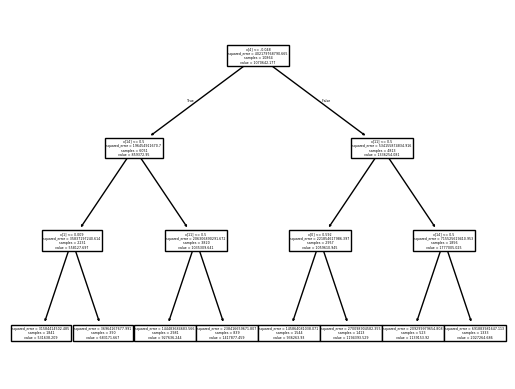

In [21]:
from sklearn import tree

tree.plot_tree(models_regresion["dt_1"])